# Impor Library dan Dataset

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import BatchNormalization, Dropout, ReLU, Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import HeNormal
from sklearn.preprocessing import PolynomialFeatures
from imblearn.over_sampling import SMOTE

tf.keras.backend.clear_session()

# Ubah URL Google Sheet menjadi format CSV
google_sheet_url = 'https://docs.google.com/spreadsheets/d/1X2RPoGIfIZJUp0IShtPdRy4fQvIgbLc_SCRdCIg-zCE/export?format=csv&gid=1492503945'

# Baca Google Sheet dalam format CSV
df = pd.read_csv(google_sheet_url)

# Preprocessing

In [ ]:
X = df.iloc[:, :-1].values  # Fitur (data sensor)
y = df.iloc[:, -1].values   # Target label

# Preprocessing label (encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_one_hot = to_categorical(y_encoded, num_classes=3)

# Menampilkan label mapping
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Label Mapping:", label_mapping)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Scaling data fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_poly)

# Menampilkan nilai minimum dan maksimum
print("Nilai minimum per fitur:", scaler.data_min_)
print("Nilai maksimum per fitur:", scaler.data_max_)

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.2, random_state=42)

Label Mapping: {'daging babi': 0, 'daging sapi': 1, 'objek tidak diketahui': 2}
Nilai minimum per fitur: [ 0.67    5.3     1.67    0.87    0.83    1.11    0.4489 12.0801  6.1506
  9.3599 13.3263 17.1453 28.09    8.851   4.611   4.399   5.883   2.7889
  1.4529  1.3861  1.8537  0.7569  0.7221  0.9657  0.6889  0.9213  1.2321]
Nilai maksimum per fitur: [3.00268000e+04 5.18501000e+03 1.17610000e+03 6.85610000e+02
 1.73018000e+03 9.63390000e+02 9.01608718e+08 1.33651379e+08
 3.04772020e+07 1.76788521e+07 5.08323697e+07 2.45001580e+07
 2.68843287e+07 6.01466197e+06 3.54582094e+06 8.95632868e+06
 4.91216461e+06 1.38321121e+06 7.95594634e+05 2.01031344e+06
 1.10257126e+06 4.70061072e+05 1.18470615e+06 6.60509818e+05
 2.99352283e+06 1.64181971e+06 9.28120292e+05]


In [ ]:
# --- Melihat hasil Polynomial Features ---

# Ambil nama fitur asli
original_features = df.columns[:-1]  # kecuali kolom target

feature_names = poly.get_feature_names_out(original_features)

# Konversi ke DataFrame
df_poly = pd.DataFrame(X_poly, columns=feature_names)

# Simpan ke file CSV
output_file = "data_polynomial.csv"
df_poly.to_csv(output_file, index=False)

print(f"File hasil polynomial feature sudah disimpan sebagai {output_file}")


File hasil polynomial feature sudah disimpan sebagai data_polynomial.csv


Jumlah data per label:
label
daging sapi              10400
daging babi              10400
objek tidak diketahui     6205
Name: count, dtype: int64


/tmp/ipython-input-3545926967.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


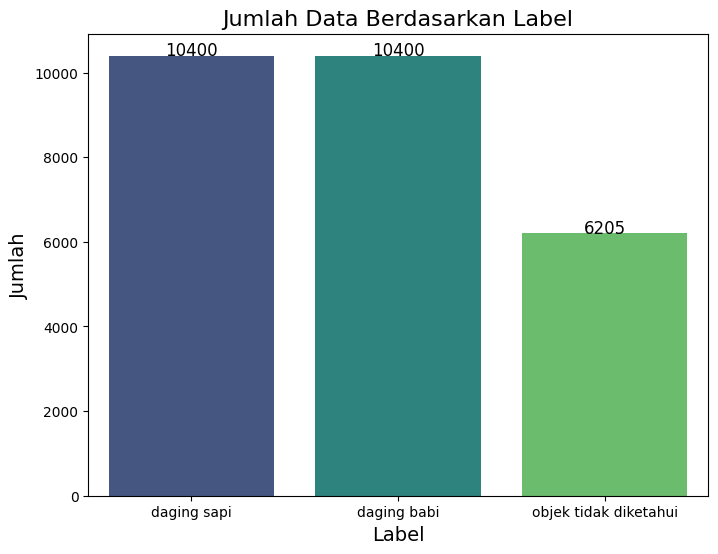

In [ ]:
import pandas as pd
import seaborn as sns

# URL Google Sheet
google_sheet_url = 'https://docs.google.com/spreadsheets/d/1X2RPoGIfIZJUp0IShtPdRy4fQvIgbLc_SCRdCIg-zCE/export?format=csv&gid=1492503945'

# Load data dari Google Sheet
df = pd.read_csv(google_sheet_url)

# Misalkan kolom terakhir adalah label
label_column = df.columns[-1]  # Kolom terakhir sebagai target label

# Hitung jumlah data berdasarkan label
label_counts = df[label_column].value_counts()

# Tampilkan jumlah data per label di console
print("Jumlah data per label:")
print(label_counts)

# Membuat grafik bar
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')

# Menambahkan judul dan label pada grafik
plt.title('Jumlah Data Berdasarkan Label', fontsize=16)
plt.xlabel('Label', fontsize=14)
plt.ylabel('Jumlah', fontsize=14)

# Menampilkan nilai di atas bar
for i, value in enumerate(label_counts.values):
    plt.text(i, value + 0.5, str(value), ha='center', fontsize=12)

# Tampilkan grafik
plt.show()

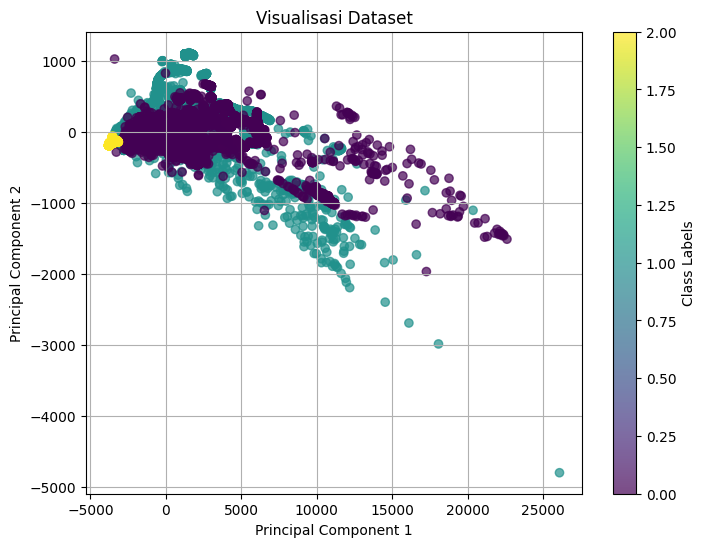

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Asumsikan X adalah dataset asli, dan y adalah labelnya.
# Lakukan PCA pada dataset asli
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualisasikan hasilnya
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.title("Visualisasi Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


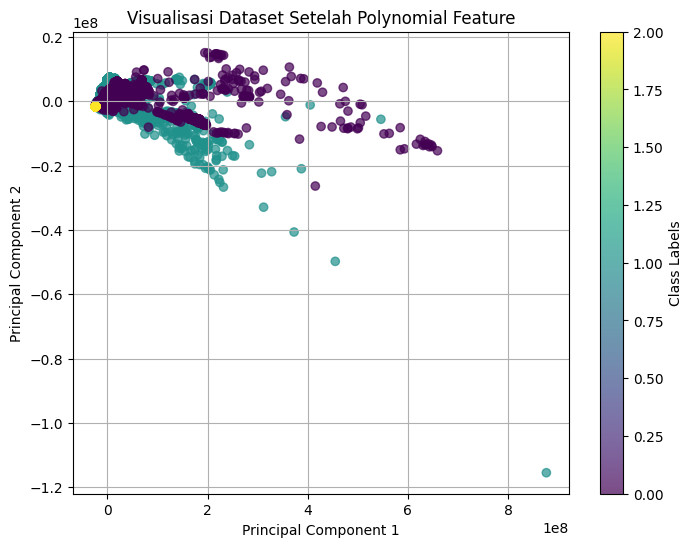

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Asumsikan X adalah dataset asli, dan y adalah labelnya.
# Lakukan PCA pada dataset asli
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_poly)

# Visualisasikan hasilnya
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.title("Visualisasi Dataset Setelah Polynomial Feature")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


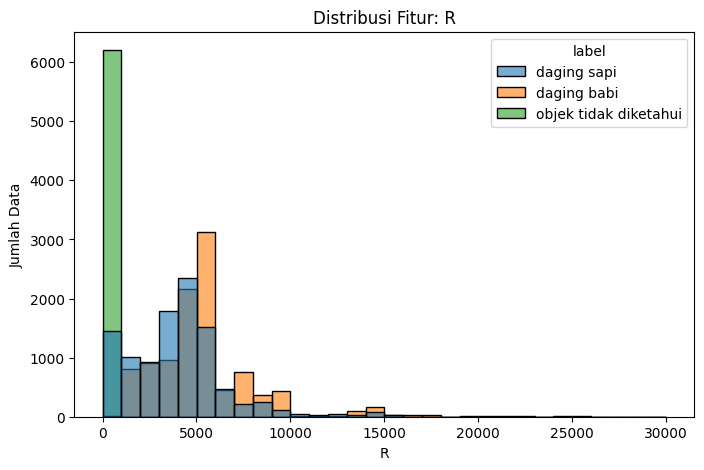

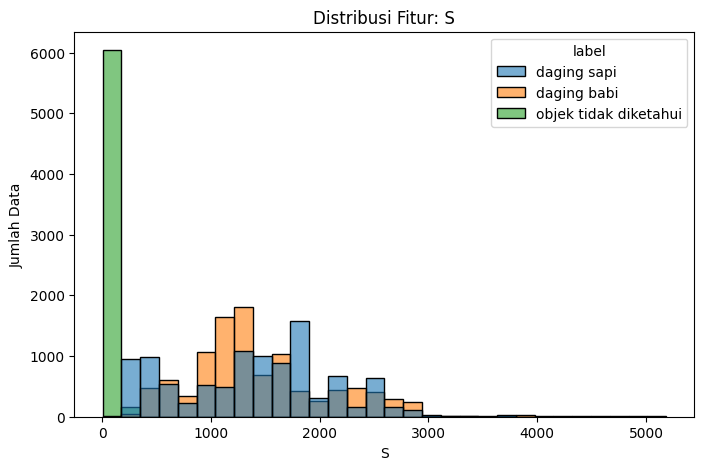

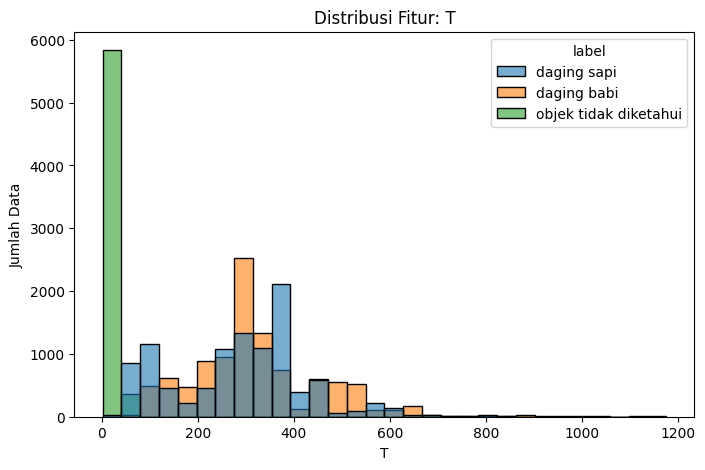

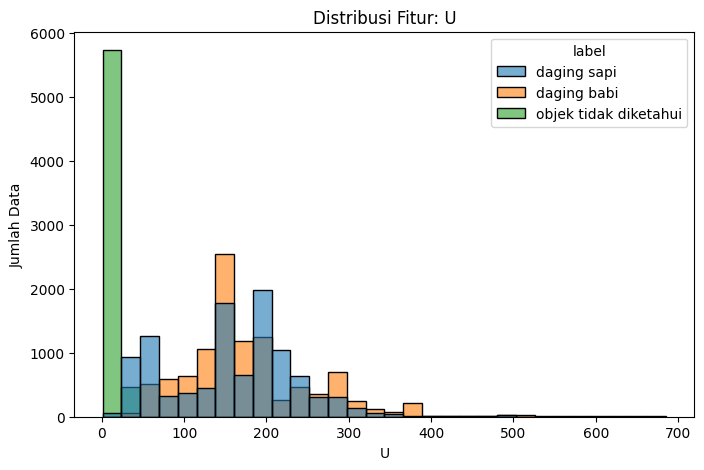

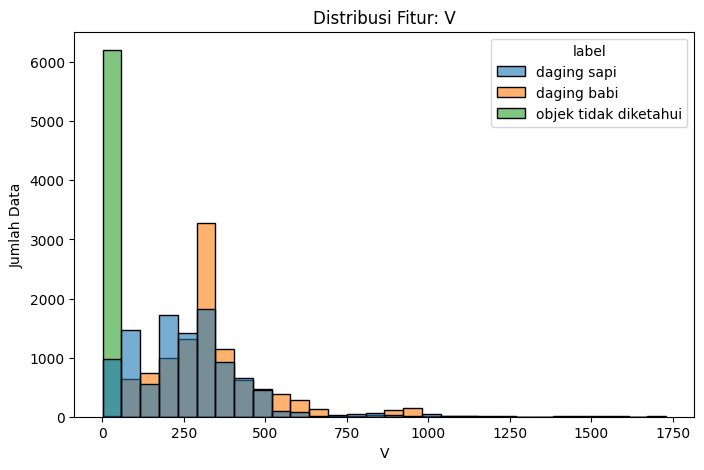

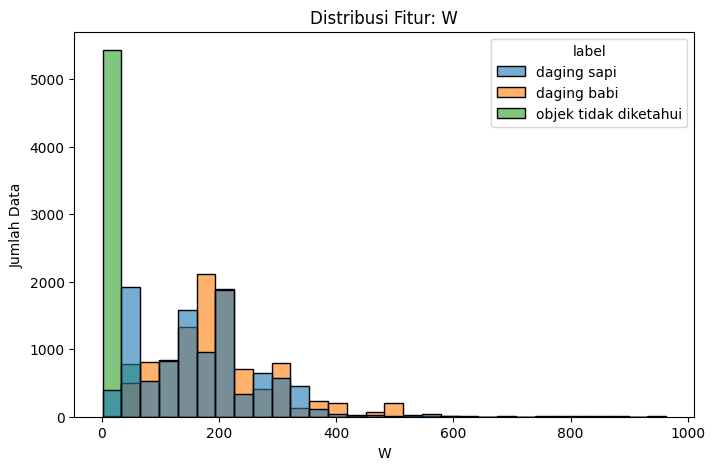

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Misal df adalah dataset kamu, dengan 6 fitur dan kolom 'label' sebagai kelas
fitur = ['R', 'S', 'T', 'U', 'V', 'W']  # ganti sesuai nama fitur aslinya

for f in fitur:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=f, hue="label", bins=30, kde=False, alpha=0.6)
    plt.title(f'Distribusi Fitur: {f}')
    plt.xlabel(f)
    plt.ylabel('Jumlah Data')
    plt.show()


# Arsitektur Model ANN

In [ ]:
# Membangun model ANN
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(units=64, kernel_initializer=HeNormal(), kernel_regularizer=l2(0.1)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=64, kernel_initializer=HeNormal(), kernel_regularizer=l2(0.1)))
model.add(BatchNormalization())
model.add(LeakyReLU(negative_slope=0.1))
model.add(Dropout(0.2))

model.add(Dense(units=64, kernel_initializer=HeNormal(), kernel_regularizer=l2(0.1)))
model.add(BatchNormalization())
model.add(LeakyReLU(negative_slope=0.1))
model.add(Dropout(0.2))

model.add(Dense(units=3, activation='softmax'))

optimizer = Adam(learning_rate=0.00005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Training

In [ ]:
# Training model ANN
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3748 - loss: 37.6861 - val_accuracy: 0.7271 - val_loss: 31.0332
Epoch 2/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6624 - loss: 29.2695 - val_accuracy: 0.7910 - val_loss: 24.0921
Epoch 3/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7300 - loss: 22.7614 - val_accuracy: 0.8193 - val_loss: 18.6605
Epoch 4/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7562 - loss: 17.6366 - val_accuracy: 0.8330 - val_loss: 14.3765
Epoch 5/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7665 - loss: 13.6071 - val_accuracy: 0.8321 - val_loss: 11.0262
Epoch 6/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7972 - loss: 10.4224 - val_accuracy: 0.8445 - val_loss: 8.4156
Epoch 7/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7978 - loss: 7.9902 - val_accuracy: 0.8461 - val_loss: 6.4296
Epoch 8/200
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8082 - loss: 6.1202

# Evaluasi Model Menggunakan Data Testing

In [ ]:
# Evaluasi model dengan data testing
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9739 - loss: 0.1732
Test Accuracy: 0.9729679822921753


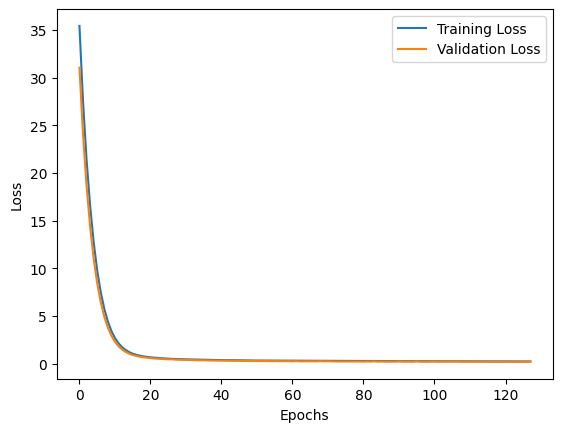

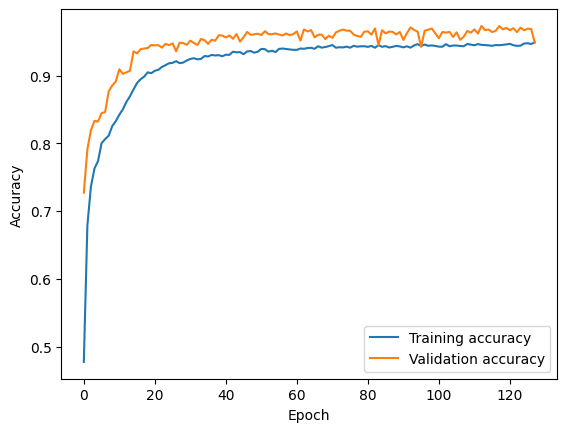

In [ ]:
import matplotlib.pyplot as plt

# Plot loss history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting training and validation accuracy
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[2002   44    0]
 [  86 2017   16]
 [   0    0 1236]]


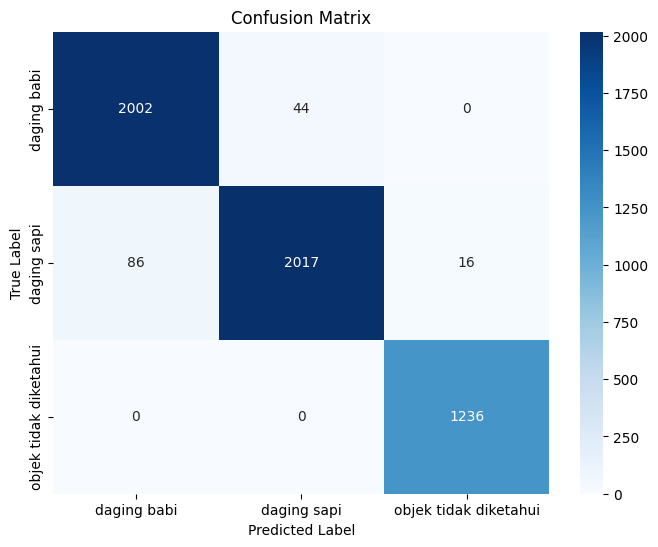

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prediksi pada data testing
y_pred_probs = model.predict(X_test)  # Probabilitas
y_pred = np.argmax(y_pred_probs, axis=1)  # Konversi ke label kelas
y_true = np.argmax(y_test, axis=1)  # Konversi one-hot encoding ke label kelas

# Membuat confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Membuat heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y_true_labels = np.argmax(y_test, axis=1)  # Ground truth labels
y_pred_labels = np.argmax(model.predict(X_test), axis=1)  # Predicted labels

# Ubah label_mapping.keys() ke daftar string
target_names = [str(label) for label in label_mapping.keys()]

# Menampilkan laporan klasifikasi
print("\nLaporan Klasifikasi:")
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names))

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Laporan Klasifikasi:
                       precision    recall  f1-score   support

          daging babi       0.96      0.98      0.97      2046
          daging sapi       0.98      0.95      0.97      2119
objek tidak diketahui       0.99      1.00      0.99      1236

             accuracy                           0.97      5401
            macro avg       0.97      0.98      0.98      5401
         weighted avg       0.97      0.97      0.97      5401



In [ ]:
# Simpan model
model.save('ann_model.keras')

# Memeriksa ukuran file model TFLite
file_path = 'ann_model.keras'
file_size = os.path.getsize(file_path)
print(f"Ukuran model TFLite: {file_size / 1024:.2f} KB")

Ukuran model TFLite: 186.89 KB


In [ ]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(poly, 'poly.pkl')

['poly.pkl']

# Evaluasi Model Menggunakan Data Evaluasi

Data yang diambil dari Google Sheet:
         R        S       T       U       V       W        label
0  5104.32  2581.90  388.97  258.52  463.21  339.30  daging sapi
1  2847.49   874.77  220.36  116.16  169.87  119.03  daging sapi
2   464.36   240.69   68.45   47.16   59.66   48.95  daging sapi
3  6622.50  2174.73  434.05  254.15  470.66  297.03  daging sapi
4  4472.74  1560.80  413.18  212.23  319.85  185.78  daging sapi
Label Mapping (Google Sheet): {'daging babi': 0, 'daging sapi': 1, 'objek tidak diketahui': 2}
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
[[2538   62    0]
 [  86 2493   22]
 [   0    0 1400]]


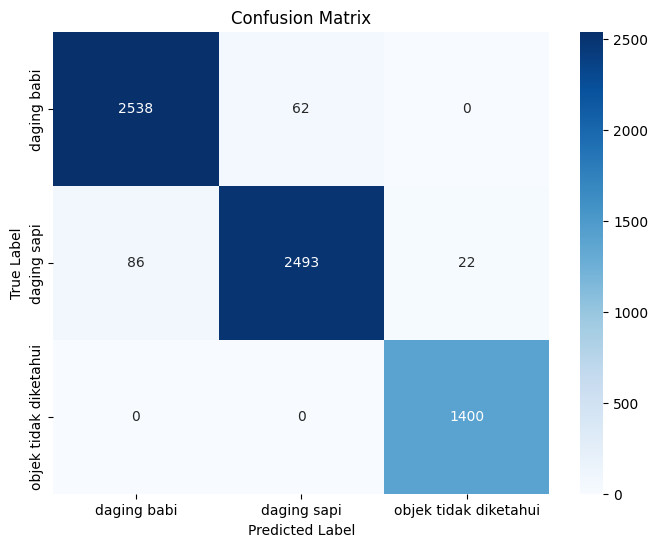


Laporan Klasifikasi:
                       precision    recall  f1-score   support

          daging babi       0.97      0.98      0.97      2600
          daging sapi       0.98      0.96      0.97      2601
objek tidak diketahui       0.98      1.00      0.99      1400

             accuracy                           0.97      6601
            macro avg       0.98      0.98      0.98      6601
         weighted avg       0.97      0.97      0.97      6601



In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.backend.clear_session()

# 1. Ubah URL Google Sheet menjadi format CSV
google_sheet_url = 'https://docs.google.com/spreadsheets/d/1X2RPoGIfIZJUp0IShtPdRy4fQvIgbLc_SCRdCIg-zCE/export?format=csv&gid=1474883880'

# 2. Baca Google Sheet dalam format CSV
test_df = pd.read_csv(google_sheet_url)

# 3. Menampilkan data untuk verifikasi
print("Data yang diambil dari Google Sheet:")
print(test_df.head())

# 4. Pisahkan fitur dan target (pastikan format kolom sesuai)
X_test = test_df.iloc[:, :-1].values  # Semua kolom kecuali terakhir
y_test_raw = test_df.iloc[:, -1].values  # Kolom terakhir sebagai label

# 5. Preprocessing label (encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test_raw)

# Konversi ke bentuk numerik
print("Label Mapping (Google Sheet):", dict(zip(le.classes_, range(len(le.classes_)))))

# Jika label di model sebelumnya adalah one-hot, ubah `y_test` ke bentuk one-hot
from tensorflow.keras.utils import to_categorical
y_test = to_categorical(y_test_encoded, num_classes=3)  # Sesuaikan jumlah kelas

# Apply PolynomialFeatures to the test data
from sklearn.preprocessing import PolynomialFeatures
poly = joblib.load('poly.pkl')  # Pastikan Anda menyimpan poly saat training
X_test_poly = poly.transform(X_test)  # Gunakan transform(), bukan fit_transform()

# 6. Scaling data menggunakan scaler yang sama
import joblib
scaler = joblib.load('scaler.pkl')  # Pastikan Anda menyimpan scaler saat training
X_test_scaled = scaler.transform(X_test_poly) # Fit & transform pada data testing

# 7. Load model yang telah disimpan
model = load_model('ann_model.keras')

# 8. Prediksi pada data testing
y_pred = np.argmax(model.predict(X_test_scaled), axis=-1)
y_true = np.argmax(y_test, axis=1)  # Ground truth kelas

# 9. Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 10. Tampilkan confusion matrix dengan visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 11. Hitung dan tampilkan laporan klasifikasi
print("\nLaporan Klasifikasi:")
# Konversi elemen le.classes_ ke string
target_names = [str(cls) for cls in le.classes_]
print(classification_report(y_true, y_pred, target_names=target_names))

In [ ]:
import tensorflow as tf

# Muat model
model = tf.keras.models.load_model('ann_model.keras')

# Tampilkan ringkasan model
model.summary()
np.set_printoptions(threshold=np.inf, linewidth=np.inf, suppress=True)

# Ambil hanya layer Dense
dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]

# Dapatkan bobot dan bias
weights = [layer.get_weights()[0] for layer in dense_layers]
biases = [layer.get_weights()[1] for layer in dense_layers]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,459 (126.80 KB)

 Trainable params: 10,691 (41.76 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 21,384 (83.54 KB)

In [ ]:
import numpy as np

def export_weights(weights, name):
    print(f"const double {name}[{weights.shape[0]}][{weights.shape[1]}] = {{")
    for i in range(weights.shape[0]):
        row = ", ".join([f"{x:.8f}" for x in weights[i]])
        print(f"  {{{row}}},")
    print("};")

# Untuk setiap layer
for i, layer in enumerate(dense_layers):
    w, b = layer.get_weights()
    print(f"\n// Layer {i+1}")
    export_weights(w, f"weights_layer_{i+1}")
    print("\nconst double bias_layer_" + str(i+1) +
          f"[{len(b)}] = {{{', '.join([f'{x:.8f}' for x in b])}}};")


// Layer 1
const double weights_layer_1[27][64] = {
  {-0.07079175, 0.00019296, 0.00241274, 0.03753258, -0.00159246, 0.07311647, 0.00583747, 0.00445384, 0.00719681, -0.01411616, 0.00122651, -0.03611688, -0.06208731, 0.01207548, -0.02786893, 0.06163809, -0.01869709, -0.00024749, 0.00005548, -0.00026470, 0.00014332, -0.07656144, -0.00661595, -0.00059975, -0.00007234, 0.00002333, -0.00862072, -0.02660563, -0.00649643, -0.00030011, -0.04070972, -0.00249004, -0.00055703, -0.02759640, 0.00496636, -0.00521360, -0.00254159, 0.02134398, 0.00021744, 0.04443325, 0.00014085, 0.00516941, -0.00034036, -0.01601742, 0.00005027, 0.02760719, -0.01978952, -0.01195080, -0.00784024, -0.03846337, -0.00029710, 0.09912584, 0.00654765, 0.00046348, -0.00065557, 0.06551123, 0.00027499, 0.04103683, -0.00836111, 0.03016246, -0.03169039, -0.00042384, -0.01023291, -0.00001687},
  {-0.02094155, 0.07664222, 0.00035494, 0.08489172, -0.02125916, 0.06539858, -0.00880705, -0.00081937, 0.01391003, 0.08131176, -0.00075144,

In [ ]:
# Parameter Batch Normalization
for i, layer in enumerate(model.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        gamma, beta, mean, var = layer.get_weights()
        print(f"\n// BatchNorm Layer {i}")
        print(f"const double bn_{i}_gamma[] = {{{', '.join([f'{x:.8f}' for x in gamma])}}};")
        print(f"const double bn_{i}_beta[] = {{{', '.join([f'{x:.8f}' for x in beta])}}};")
        print(f"const double bn_{i}_mean[] = {{{', '.join([f'{x:.8f}' for x in mean])}}};")
        print(f"const double bn_{i}_variance[] = {{{', '.join([f'{x:.8f}' for x in var])}}};")


// BatchNorm Layer 2
const double bn_2_gamma[] = {1.31210756, 1.18787265, 0.99055612, 1.14638019, 1.01586699, 1.20471251, 0.95788532, 0.95486146, 0.87937480, 0.98067540, 1.05441749, 1.10625470, 1.24824190, 1.26259446, 1.28369868, 1.05960131, 1.02342880, 0.87581944, 0.82308096, 1.26173782, 0.83111238, 1.27869236, 1.03447008, 1.22144091, 1.16749310, 0.78691071, 1.20818913, 1.14062965, 1.32203221, 1.04831564, 1.16683304, 0.96957302, 1.12273991, 1.10410869, 1.14842641, 1.07091975, 1.11722064, 1.15505624, 1.08200800, 1.23866570, 1.21903682, 1.14443016, 1.14828420, 1.14980686, 0.79286802, 1.11769640, 1.19181859, 0.99956149, 1.11834049, 1.11308086, 0.77141368, 1.09265041, 1.03568089, 1.10458183, 1.11508834, 1.17214227, 1.24544585, 1.09300709, 0.95016372, 1.10106063, 1.05898619, 0.87792736, 1.09057760, 0.75293809};
const double bn_2_beta[] = {-0.00010493, 0.00007659, 0.00921085, 0.00219679, -0.00729122, 0.00790425, 0.00791432, 0.00810952, 0.01087780, 0.00490603, 0.00123442, -0.00129054, -0.01

In [ ]:
import numpy as np
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input
import joblib

# Data input contoh
input_values = np.array([[6871.52,2208.67,509.17,259.40,387.80,251.42]])

# Preprocessing
poly = joblib.load('poly.pkl')
scaler = joblib.load('scaler.pkl')

# Transformasi input
X_poly = poly.transform(input_values)
print("\n2. Setelah Polynomial Features (degree=2):")
print(X_poly)
print("Shape setelah polynomial:", X_poly.shape)

X_scaled = scaler.transform(X_poly)
print("\n3. Setelah Scaling:")
print(X_scaled)
print("Shape setelah scaling:", X_scaled.shape)

# Muat model
model = load_model('ann_model.keras')

## SOLUSI UTAMA YANG PASTI BEKERJA:
# 1. Buat model baru dengan Functional API yang mengekstrak semua layer

# Pertama, pastikan model asli bisa melakukan prediksi
print("Test prediksi dengan model asli...")
try:
    pred = model.predict(X_scaled)
    print("Prediksi berhasil:", pred)
except Exception as e:
    print("Error prediksi awal:", str(e))

# 2. Bangun model baru untuk ekstraksi layer
input_layer = Input(shape=(27,), name='input_layer')
x = input_layer

# Rekonstruksi semua layer
outputs = []
for layer in model.layers:
    x = layer(x)
    outputs.append(x)

# Buat model baru
activation_model = Model(inputs=input_layer, outputs=outputs)

# 3. Dapatkan aktivasi dengan cara yang lebih aman
print("\nMendapatkan aktivasi layer...")
try:
    activations = activation_model.predict(X_scaled)

    # Tampilkan output setiap layer
    for i, (layer, activation) in enumerate(zip(model.layers, activations)):
        print(f"\nLayer {i+1}: {layer.name} ({layer.__class__.__name__})")
        print("Output shape:", activation.shape)

        if isinstance(layer, Dense):
            print(f"Bobot shape: {layer.get_weights()[0].shape}")
            print(f"Bias shape: {layer.get_weights()[1].shape}")
            print("Contoh output:", activation[0][:6])
        else:
            print("Output:", activation)

except Exception as e:
    print("Error saat mendapatkan aktivasi:", str(e))
    print("\nCoba alternatif berikut:")

    # Alternatif: Ekstraksi layer satu per satu
    print("\nAlternatif: Ekstraksi layer per layer")
    intermediate_outputs = []
    intermediate_input = X_scaled

    for i, layer in enumerate(model.layers):
        try:
            # Buat model sementara untuk layer ini saja
            temp_model = Model(inputs=model.input, outputs=layer.output)
            layer_output = temp_model.predict(intermediate_input)
            intermediate_outputs.append(layer_output)

            print(f"\nLayer {i+1}: {layer.name}")
            print("Output shape:", layer_output.shape)
            intermediate_input = layer_output  # Output menjadi input berikutnya

        except Exception as le:
            print(f"Error di layer {i+1} ({layer.name}):", str(le))
            break

# Prediksi akhir
print("\n=== HASIL PREDIKSI AKHIR ===")
final_pred = model.predict(X_scaled)
print("Probabilitas kelas:", final_pred)
print("Kelas prediksi:", le.inverse_transform([np.argmax(final_pred)]))


2. Setelah Polynomial Features (degree=2):
[[    6871.52           2208.67            509.17            259.4             387.8             251.42       47217787.11040001 15176920.0784      3498771.8384      1782472.288       2664775.456       1727637.5584      4878223.1689      1124588.5039       572928.998        856522.226        555303.8114       259254.0889       132078.698        197456.126        128015.5214        67288.36         100595.32          65218.348        150388.84          97500.676         63212.0164    ]]
Shape setelah polynomial: (1, 27)

3. Setelah Scaling:
[[0.22882902 0.42538482 0.43212452 0.37755937 0.22376615 0.26012179 0.0523706  0.11355595 0.11479946 0.10082464 0.05242256 0.07051471 0.18145144 0.18697332 0.16157757 0.09563274 0.1130456  0.1874275  0.16601103 0.09822094 0.11610486 0.14314674 0.08491106 0.09873809 0.05023786 0.05938521 0.06810633]]
Shape setelah scaling: (1, 27)
Test prediksi dengan model asli...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Predi